# Voice Activity Detection of Human Speech from Background Noise

In [ ]:
# Goal: Use a VAD model pre-trained on human speech to identify segments of speech from other types of
# sound including traffic and party background noise, clapping and classical music

# Audio used:
# -	Recording of child talking in Chinese, then audience clapping, then classical music orchestra
# - Brief conversation held with 2 types of background noise that both fade in, first traffic noise 
#   from NYC at a similar or higher volume than the speech, and second a crowded party

# Date last updated: 1/21/2025
# Author: Kay Rubio

In [2]:
# Check python version and compatibility with Librosa
!python3 --version

Python 3.12.8


In [64]:
# https://github.com/snakers4/silero-vad/tree/master
# !pip3 install silero-vad

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
import IPython.display as ipd
from IPython.display import Audio

In [80]:
# Use sampling rate of 16000 throughout project
SR = 16000

In [74]:
# Load audio with Librosa.load
audio_folder = "Sounds/sample_audios/"
# Child talking, clapping, then classical music
child_piano, sr = librosa.load(audio_folder+"child_piano.wav", sr=SR)

# Brief conversation with background noise
convo, sr = librosa.load(audio_folder+"convo_with_noise.wav", sr=SR)

## Helper Methods

In [8]:
# Function to plot a waveform with title and optional section highlights based on timestamps
def plotWaveform(audio, title, sections=[], sections2=[]):
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(audio, sr=SR, alpha=0.5, color='blue')
    plt.title(title)
    plt.xlabel("Time (sec)") 
    plt.ylabel("Amplitude")
    for section in sections:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='purple', alpha=0.3)
    for section in sections2:
        start, end = float(section['start']), float(section['end'])
        plt.axvspan(start, end, color='yellow', alpha=0.3)
    plt.show()

In [11]:
# Function that loops through all the frames, and if they are consecutive 1's or 0's, lump them 
# together as one section, and find the timestamps that correspond to the first frame and last frame in 
# each section
# arguments:
#    vad_output in format [0, 0, 1, 1, ...] where each 1 = a frame with sound, 0 = frame with silence
#    frame_length
#    frame_shift/hop_length
#    sound, where 1 will provide timestamps for the sounds, and 0 provides timestamps for the silences
# Returns an array of vocalizations, with elements in format {'start': time in seconds, 'end': time in seconds}

def convert_vad_output_to_timestamps(vad_output, frame_length, frame_shift, sound=1):
    sections = []
    sections_start = None

    # Loop through each frame in the VAD output
    for i, frame in enumerate(vad_output):
        # Calculate the start and end times of the current frame
        start_time = i * frame_shift / 1000  # Convert to seconds
        end_time = start_time + frame_length / 1000  # Convert to seconds

        if frame == sound:
            if sections_start is None:
                # Vocals starts here
                sections_start = start_time
        else:
            if sections_start is not None:
                # Vocals ends here
                sections.append({
                    'start': f"{sections_start:.3f}",
                    'end': f"{end_time:.3f}"
                })
                sections_start = None

    # Handle the case if the last frame has speech
    if sections_start is not None:
        sections.append({
            'start': f"{sections_start:.3f}",
            'end': f"{end_time:.3f}"
        })

    return sections

In [83]:
# Function to spit an audio into an array of individual audios by timestamp.
# Assumes timestamps are in format {'start': time in seconds, 'end': time in seconds}
def splitAudioByTimestamps(audio, timestamps):
    audio_array = []
    for i, ts in enumerate(timestamps):
        start_sample = int(float(ts['start']) * SR) # convert start time into sample index
        end_sample = int(float(ts['end']) * SR)
        segment = audio[start_sample:end_sample] # Extract the segment using start and ending sample index
        audio_array.append(segment) # append segment into the array
    return audio_array

In [ ]:
# Function to export an array of individual sounds (need to create a folder with matching foldername first)
def exportArrayOfAudio(array, foldername, filename):
    for i, sound in enumerate(array):
    	sf.write(f'{foldername}/{filename}{i}.wav', sound, SR)

## Human-selected speech segments used as a baseline to evaluate model accuracy below

In [13]:
# Manually created timestamps for comparison with VAD-extracted timestamps
child_piano_timestamps_human = [{'start': '0.5', 'end': '13.4'}]
convo_timestamps_human = [
    {'start': '0.525', 'end': '2.0'},
    {'start': '3.025', 'end': '4.2'},
    {'start': '4.47', 'end': '5.63'},
    {'start': '6.1', 'end': '8.6'},
    {'start': '8.77', 'end': '9.3'},
    {'start': '9.7', 'end': '10.25'},
    {'start': '10.7', 'end': '12.23'}
]

In [1]:
# ipd.Audio(audio_folder+"child_piano.wav")

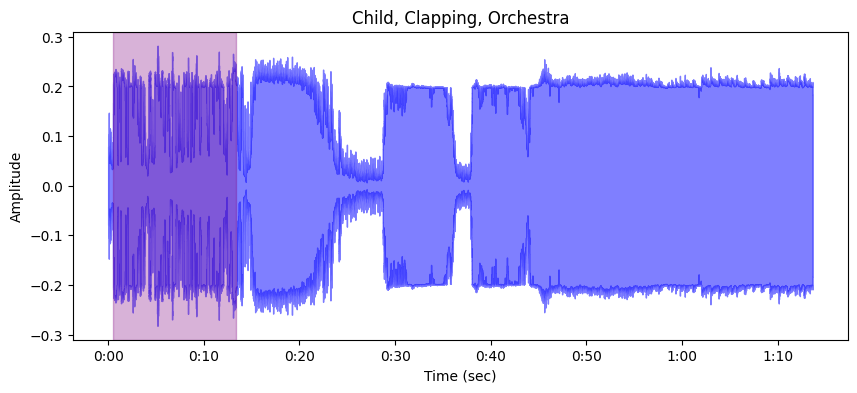

In [75]:
plotWaveform(child_piano, 'Child, Clapping, Orchestra', child_piano_timestamps_human)

In [2]:
# ipd.Audio(audio_folder+"convo_with_noise.wav")

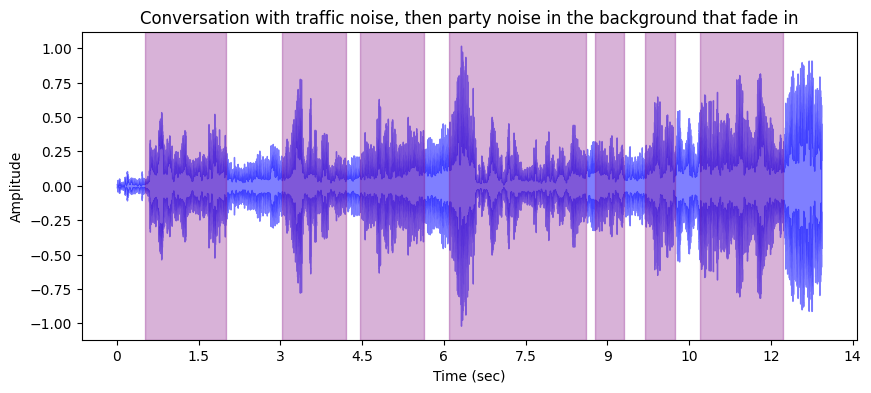

In [26]:
plotWaveform(convo, 'Conversation with traffic noise, then party noise in the background that fade in', convo_timestamps_human)

## Use Silero-Vad to extract speech

In [ ]:
# https://github.com/snakers4/silero-vad

In [66]:
from silero_vad import load_silero_vad, read_audio, get_speech_timestamps
model = load_silero_vad()
wav = read_audio('Sounds/sample_audios/convo_with_noise.wav')
convo_timestamps_silero = get_speech_timestamps(
  wav,
  model,
  return_seconds=True,  # Return speech timestamps in seconds (default is samples)
)
convo_timestamps_silero

[{'start': 0.5, 'end': 2.3},
 {'start': 3.1, 'end': 4.3},
 {'start': 4.5, 'end': 6.0},
 {'start': 6.4, 'end': 12.9}]

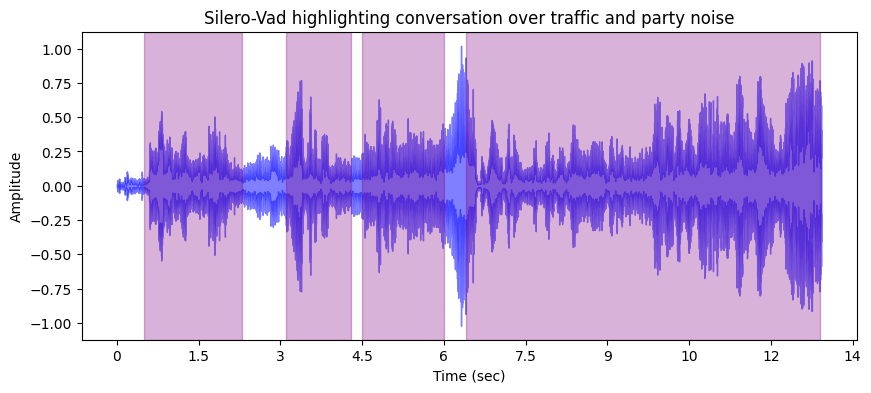

In [88]:
plotWaveform(convo, 'Silero-Vad highlighting conversation over traffic and party noise', convo_timestamps_silero)

In [ ]:
# Above, this shows that Silero-Vad was really good at pulling out the speech from the rather loud
# traffic noise, but struggled with the party, probably because the party background noise was a mix
# of voices, only slighty lower volume than the target voice

In [72]:
wav = read_audio('Sounds/sample_audios/child_piano.wav')
child_piano_timestamps_silero = get_speech_timestamps(
  wav,
  model,
  return_seconds=True,  # Return speech timestamps in seconds (default is samples)
)
child_piano_timestamps_silero

[{'start': 0.5, 'end': 3.8},
 {'start': 4.2, 'end': 7.5},
 {'start': 7.7, 'end': 13.9}]

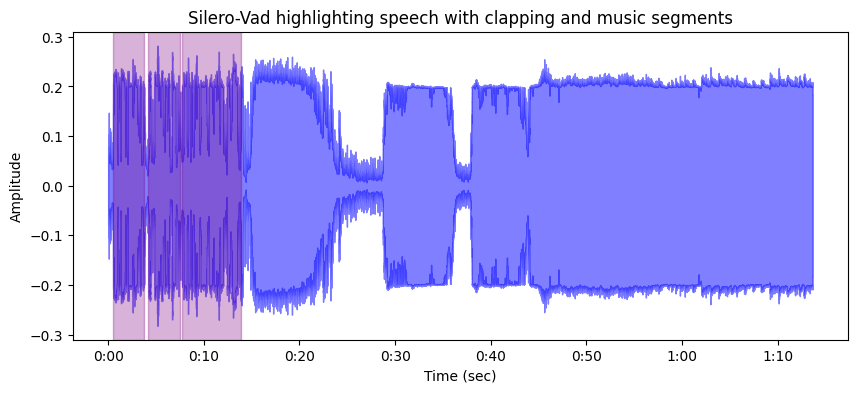

In [89]:
plotWaveform(child_piano, 'Silero-Vad highlighting speech with clapping and music segments', child_piano_timestamps_silero)

In [ ]:
# This result shows Silero-Vad is really good at picking out child's speech (even in another language)
# from clapping noise, orchestra and piano music

In [86]:
# Split the audio file into pieces for just speech
child_piano_speech = splitAudioByTimestamps(child_piano, child_piano_timestamps_silero)
len(child_piano_speech)

3

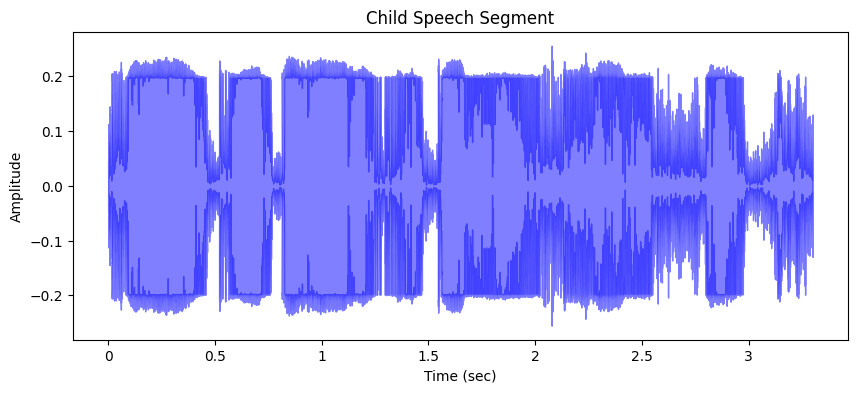

In [87]:
# Check the waveform for a speech segment highlighted by Silero-Vad
plotWaveform(child_piano_speech[0], 'Child Speech Segment')

In [ ]:
# Export those audio files of speech-only to computer for future use
exportArrayOfAudio(child_piano_speech, 'child_piano_speech', 'speech')